# GenAI Adoption vs. GDP Analysis

**Question:** Is real-world GenAI adoption really as widespread as advertising and media coverage suggest, and how does it relate to GDP per capita?

**Data Source:** 

[Our World in Data: Generative AI vs. GDP per Capita](https://ourworldindata.org/) (CC BY)

Microsoft (2026)Eurostat, OECD, IMF, and World Bank (2026) Our World in Data – with minor processing by Our World in Data

**Project Info:**

This notebook was built collaboratively with Claude as part of Anthropic's AI Fluency course. See `progress-notes.md` and `project-plan.md` in this repo for the full breakdown of how work was divided between human judgment and AI assistance. A lot of the analysis was conducted and completed through a back and forth conversation with Claude, speaking about what challenged my assumptions and discussing outliers as well as surprising features of this analysis.

In [2]:
import os
import pandas as pd

os.makedirs('charts', exist_ok=True)

df = pd.read_csv('data/cleaned/genai_adoption_clean_full.csv')
df['date'] = pd.to_datetime(df['date'])
df.head()


,country,code,date,adoption_pct,gdp_per_capita,region
0,Afghanistan,AFG,2025-06-30,5.1,1983.8126,Asia
1,Afghanistan,AFG,2025-12-31,5.6,1983.8126,Asia
2,Afghanistan,AFG,2026-03-31,6.1,1983.8126,Asia
3,Albania,ALB,2025-06-30,15.8,21641.0740,Europe
4,Albania,ALB,2025-12-31,16.5,21641.0740,Europe


## Question 1: Does GDP per capita correlate with GenAI adoption?

Using the March 2026 snapshot to avoid counting each country three times.


In [3]:
snapshot = df[df['date'] == '2026-03-31'].dropna(subset=['gdp_per_capita', 'region'])
corr = snapshot['gdp_per_capita'].corr(snapshot['adoption_pct'])
print(f"Correlation between GDP per capita and adoption rate: {corr:.3f}")
print(f"Countries in this snapshot: {len(snapshot)}")


Correlation between GDP per capita and adoption rate: 0.846
Countries in this snapshot: 141


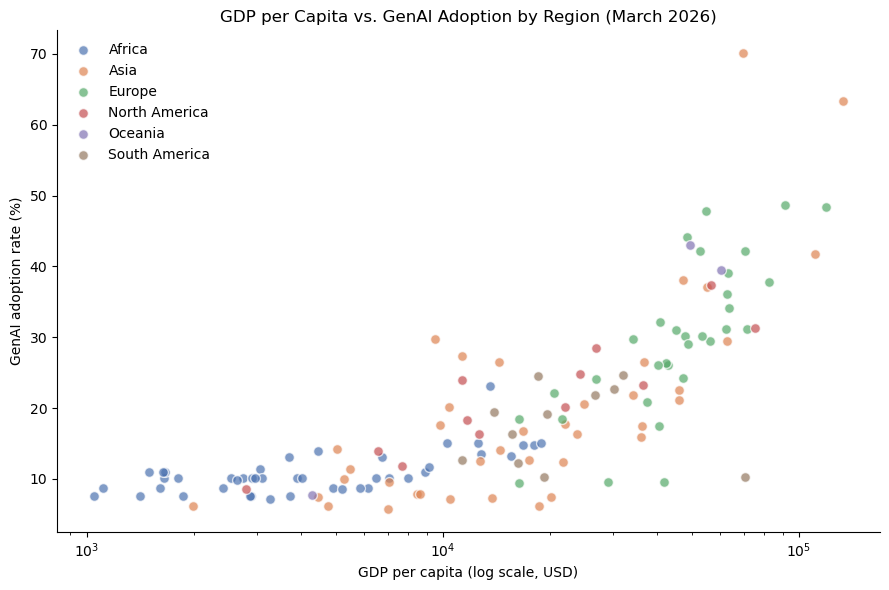

In [4]:
import matplotlib.pyplot as plt

regions = sorted(snapshot['region'].unique())
colors = dict(zip(regions, ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']))

fig, ax = plt.subplots(figsize=(9,6))
for region in regions:
    sub = snapshot[snapshot['region'] == region]
    ax.scatter(sub['gdp_per_capita'], sub['adoption_pct'], alpha=0.7, s=50,
               color=colors[region], edgecolor='white', label=region)
ax.set_xscale('log')
ax.set_xlabel('GDP per capita (log scale, USD)')
ax.set_ylabel('GenAI adoption rate (%)')
ax.set_title('GDP per Capita vs. GenAI Adoption by Region (March 2026)')
ax.spines[['top','right']].set_visible(False)
ax.legend(loc='upper left', frameon=False)
plt.tight_layout()
plt.savefig('charts/q1_gdp_vs_adoption_by_region.png', dpi=150)
plt.show()


**Analysis:**

There is a strong correlation between GDP per capita and adoption rate of Generative AI across the world, which is 0.846. This indicates that almost all countries and regions follow a pattern where the adoption rate of GenAI increases depending on the GDP of a country. Although 0.846 is a high correlation, this doesn't fully explain the pattern as some variation in adoption (about 15%) is left unaccounted for by GDP alone, which is explored further in Question 3.


## Question 2: Which countries saw adoption decrease between June 2025 and March 2026?


In [5]:
early = df[df['date'] == '2025-06-30'][['country', 'adoption_pct']].rename(columns={'adoption_pct': 'early_pct'})
late = df[df['date'] == '2026-03-31'][['country', 'adoption_pct']].rename(columns={'adoption_pct': 'late_pct'})
change = early.merge(late, on='country')
change['change'] = change['late_pct'] - change['early_pct']

declined = change[change['change'] < 0].sort_values('change')
print(f"Countries with declining adoption: {len(declined)}")
print("\nSmallest growth (closest to declining):")
print(change.sort_values('change').head(5))


Countries with declining adoption: 0

Smallest growth (closest to declining):
              country  early_pct  late_pct  change
137           Ukraine        9.1       9.4     0.3
100  Papua New Guinea        7.2       7.7     0.5
127             Syria        6.7       7.5     0.8
46             Gambia       10.6      11.4     0.8
69              Kenya        7.8       8.7     0.9


**Analysis:**

Not a single country saw Generative AI adoption decline between June 2025 and March 2026. Every one of the 147 countries analyzed grew, even the slowest (Ukraine), which still increased by 0.3 percentage points. This indicates a consistent global upward trend in adoption, not just an average masking mixed results underneath.


## Question 3: Which countries have adoption higher or lower than their GDP rank would predict?

**A quick note on "rank":** ranking means ordering countries from 1st to last. Rank 1 in GDP is the richest country, rank 1 in adoption is the highest-adoption country. The "rank gap" below is `GDP rank − adoption rank` for each country. A gap near 0 means a country's wealth position and adoption position roughly match. A large gap means the two orderings disagree; something other than wealth is pushing that country's adoption up or down relative to where its wealth alone would place it. Rank is used instead of raw numbers because GDP (dollars) and adoption (percent) aren't on comparable scales.


In [6]:
snapshot = df[df['date'] == '2026-03-31'].dropna(subset=['gdp_per_capita']).copy()
snapshot['gdp_rank'] = snapshot['gdp_per_capita'].rank(ascending=False)
snapshot['adoption_rank'] = snapshot['adoption_pct'].rank(ascending=False)
snapshot['rank_gap'] = snapshot['gdp_rank'] - snapshot['adoption_rank']

print("Over-performers (adoption higher than GDP rank predicts):")
print(snapshot.sort_values('rank_gap', ascending=False).head(5)[['country','gdp_rank','adoption_rank','rank_gap']])

print("\nUnder-performers (adoption lower than GDP rank predicts):")
print(snapshot.sort_values('rank_gap', ascending=True).head(5)[['country','gdp_rank','adoption_rank','rank_gap']])


Over-performers (adoption higher than GDP rank predicts):
        country  gdp_rank  adoption_rank  rank_gap
203      Jordan      91.0           26.5      64.5
221     Lebanon      85.0           32.0      53.0
263  Mozambique     138.0           93.5      44.5
239      Malawi     136.0           93.5      42.5
434     Vietnam      75.0           33.5      41.5

Under-performers (adoption lower than GDP rank predicts):
          country  gdp_rank  adoption_rank  rank_gap
164        Guyana       8.0           96.5     -88.5
326        Russia      34.0          113.5     -79.5
407  Turkmenistan      63.0          139.0     -76.0
17        Armenia      59.0          134.0     -75.0
32        Belarus      47.0          112.0     -65.0


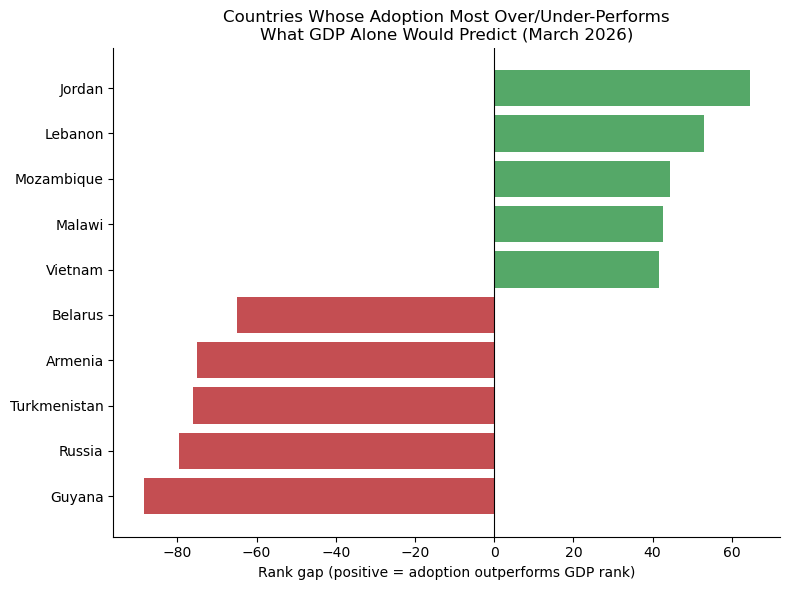

In [7]:
top_over = snapshot.sort_values('rank_gap', ascending=False).head(5)
top_under = snapshot.sort_values('rank_gap', ascending=True).head(5)
combined = pd.concat([top_over, top_under]).sort_values('rank_gap')

fig, ax = plt.subplots(figsize=(8,6))
bar_colors = ['#C44E52' if v < 0 else '#55A868' for v in combined['rank_gap']]
ax.barh(combined['country'], combined['rank_gap'], color=bar_colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Rank gap (positive = adoption outperforms GDP rank)')
ax.set_title('Countries Whose Adoption Most Over/Under-Performs\nWhat GDP Alone Would Predict (March 2026)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('charts/q3_gdp_adoption_outliers.png', dpi=150)
plt.show()


**Analysis:**

In terms of outliers:
- Jordan, Lebanon, Mozambique, Malawi, and Vietnam have adopted Generative AI at rates higher relative to their GDP rank, with Jordan having the largest gap at 64.5 rank positions.
- Guyana, Russia, Turkmenistan, Armenia, and Belarus show adoption lagging lower than their GDP rank would predict.

This is worth investigating further, as these outliers have values that are unexpected given the overall GDP-adoption relationship.


## Question 4: Is high adoption broad-based, or concentrated in a few standout countries?

Comparing the global median adoption rate to the top 10 countries, and the full distribution across all 147 countries (March 2026).


In [8]:
snapshot = df[df['date'] == '2026-03-31']
median_val = snapshot['adoption_pct'].median()
top10 = snapshot.sort_values('adoption_pct', ascending=False).head(10)
top10_avg = top10['adoption_pct'].mean()

print(f"Median adoption (March 2026): {median_val:.1f}%")
print(f"Top 10 countries average: {top10_avg:.1f}%")
print(f"Gap: {top10_avg - median_val:.1f} percentage points")
print("\nTop 10 countries:")
print(top10[['country', 'adoption_pct']])


Median adoption (March 2026): 14.8%
Top 10 countries average: 49.2%
Gap: 34.4 percentage points

Top 10 countries:
                  country  adoption_pct
416  United Arab Emirates          70.1
344             Singapore          63.4
290                Norway          48.6
188               Ireland          48.4
131                France          47.8
365                 Spain          44.2
278           New Zealand          43.0
419        United Kingdom          42.2
275           Netherlands          42.1
320                 Qatar          41.8


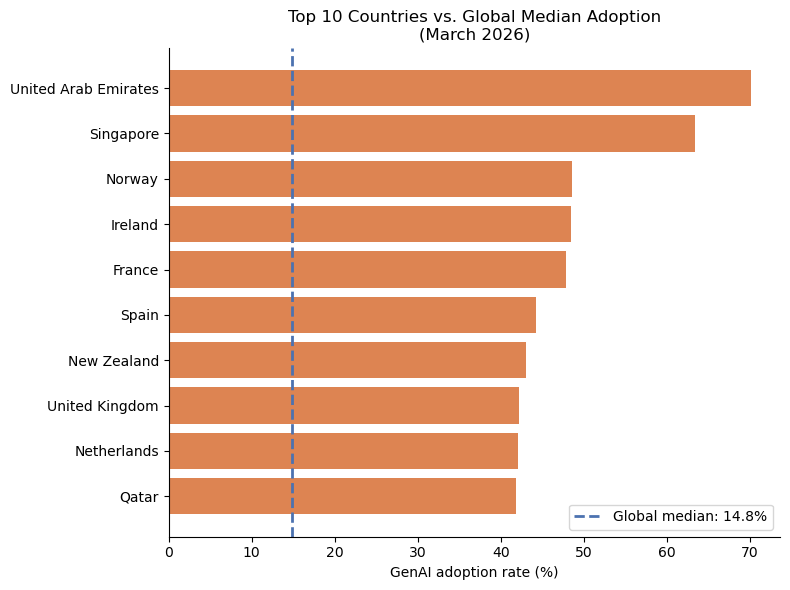

In [9]:
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(top10['country'][::-1], top10['adoption_pct'][::-1], color='#DD8452')
ax.axvline(median_val, color='#4C72B0', linestyle='--', linewidth=2, label=f'Global median: {median_val:.1f}%')
ax.set_xlabel('GenAI adoption rate (%)')
ax.set_title('Top 10 Countries vs. Global Median Adoption\n(March 2026)')
ax.legend(loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('charts/q4_median_vs_top10.png', dpi=150)
plt.show()


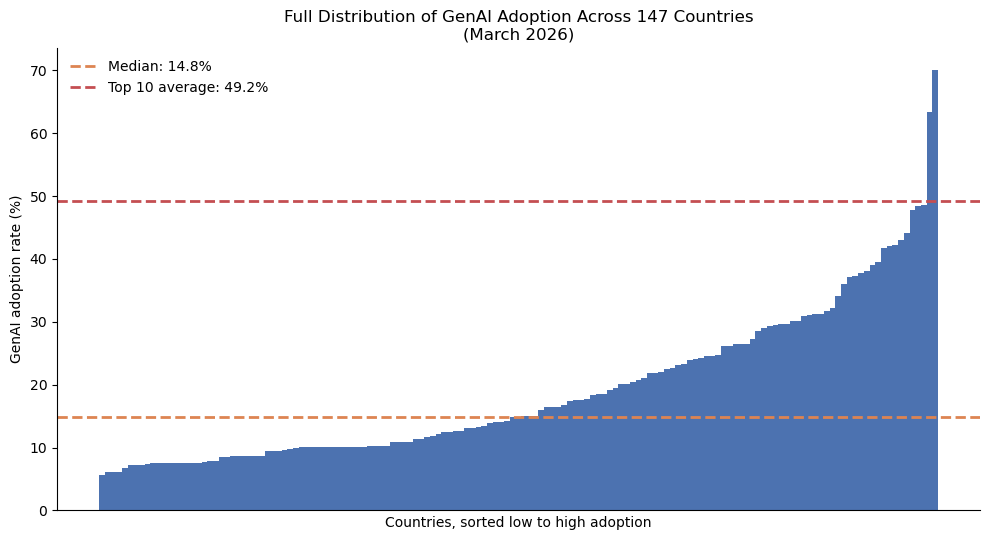

In [10]:
sorted_snapshot = snapshot.sort_values('adoption_pct').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10,5.5))
ax.bar(range(len(sorted_snapshot)), sorted_snapshot['adoption_pct'], color='#4C72B0', width=1.0)
ax.axhline(median_val, color='#DD8452', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}%')
ax.axhline(top10_avg, color='#C44E52', linestyle='--', linewidth=2, label=f'Top 10 average: {top10_avg:.1f}%')
ax.set_xlabel('Countries, sorted low to high adoption')
ax.set_ylabel('GenAI adoption rate (%)')
ax.set_title('Full Distribution of GenAI Adoption Across 147 Countries\n(March 2026)')
ax.set_xticks([])
ax.spines[['top','right']].set_visible(False)
ax.legend(loc='upper left', frameon=False)
plt.tight_layout()
plt.savefig('charts/q4_full_distribution.png', dpi=150)
plt.show()


**Analysis:**

The typical country's Generative AI adoption is at 14.8%, but the top 10 countries average around 50%. This indicates that leading nations have almost 3.5x more adoption, led by the UAE at 70.1% and Singapore at 63.4%. This makes it seem like AI adoption isn't as widespread as advertising suggests. The hype isn't fabricated, but it reflects a small group of leading countries, not the typical global experience.


## Question 5: Do regions cluster in adoption independent of GDP?

Comparing average adoption and average GDP per capita by world region (March 2026).


In [11]:
region_stats = df[df['date'] == '2026-03-31'].dropna(subset=['gdp_per_capita', 'region']).groupby('region').agg(
    avg_adoption=('adoption_pct', 'mean'),
    avg_gdp=('gdp_per_capita', 'mean'),
    n_countries=('country', 'count')
).round(1)
region_stats['adoption_rank'] = region_stats['avg_adoption'].rank(ascending=False)
region_stats['gdp_rank'] = region_stats['avg_gdp'].rank(ascending=False)
region_stats = region_stats.sort_values('adoption_rank')

print(region_stats)


               avg_adoption  avg_gdp  n_countries  adoption_rank  gdp_rank
region                                                                    
Oceania                30.1  37969.6            3            1.0       2.0
Europe                 29.6  49749.2           32            2.0       1.0
North America          21.5  24545.1           12            3.0       5.0
Asia                   19.6  26774.5           39            4.0       3.0
South America          17.7  24912.9           11            5.0       4.0
Africa                 10.8   5761.9           44            6.0       6.0


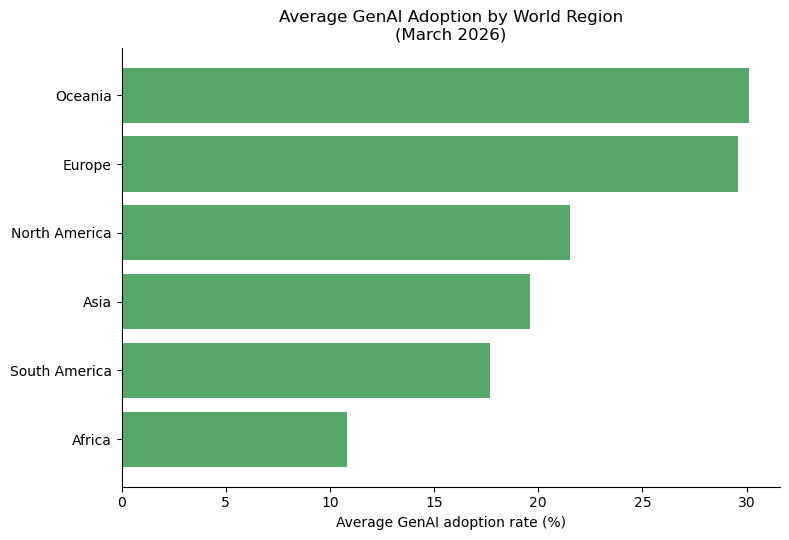

In [12]:
region_sorted = region_stats.sort_values('avg_adoption', ascending=True)

fig, ax = plt.subplots(figsize=(8,5.5))
ax.barh(region_sorted.index, region_sorted['avg_adoption'], color='#55A868')
ax.set_xlabel('Average GenAI adoption rate (%)')
ax.set_title('Average GenAI Adoption by World Region\n(March 2026)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('charts/q5_regional_adoption.png', dpi=150)
plt.show()


**Analysis:**

Oceania (30.1%) and Europe (29.6%) lead in average adoption, while Africa is lowest (10.8%). This shows that GenAI adoption largely tracks a country's GDP ranking, supporting the findings in Question 1. However, region alone doesn't fully explain adoption independent of wealth as North America and Asia's regional rankings don't perfectly match their GDP rankings, as shown in the outlier analysis.


## Summary

Overall, GenAI adoption is strongly tied to a country's GDP. Wealthier nations consistently adopt more, and this held true across nearly every region I looked at. But wealth doesn't explain everything as a handful of countries like Jordan and Vietnam are adopting far more than their GDP would predict, while countries like Guyana and Russia are adopting far less, which is worth digging into further. One of the clearest findings was that not a single country saw adoption decline over the period studied since growth was universal. But the most important finding, for my original question, was the gap between the typical country (14.8% adoption) and the leading countries (about 50%). This tells me that AI adoption headlines aren't lying, but they're describing a small group of leaders, not the world as a whole.
